# Dataset Structure EDA
## Dataset loading

In [16]:
from daily_flow.analytics.datasets.loader import load_mood_mart_sync
from daily_flow.analytics.datasets.prepare import drop_private_columns

# Load the mood dataset used for analysis
raw_df = load_mood_mart_sync()
df = drop_private_columns(raw_df)

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 268 entries, 2025-01-03 to 2026-02-27
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   common_mood_log  180 non-null    UInt8
 1   joy              144 non-null    UInt8
 2   interest         145 non-null    UInt8
 3   calm             144 non-null    UInt8
 4   energy           144 non-null    UInt8
 5   anxiety          144 non-null    UInt8
 6   sadness          144 non-null    UInt8
 7   irritation       144 non-null    UInt8
 8   fatigue          144 non-null    UInt8
 9   fear             144 non-null    UInt8
 10  confidence       144 non-null    UInt8
 11  sleep            143 non-null    UInt8
dtypes: UInt8(12)
memory usage: 8.4 KB


The dataset contains daily mood observations indexed by date. 
Each row represents a day and includes a general mood score (`common_mood_log`) 
as well as several emotion-specific mood features.

The presence of missing values indicates that the dataset was collected 
under different logging regimes across time, where some features were 
introduced later than others.

## Dataset overview

In [17]:
df.tail()

,common_mood_log,joy,interest,calm,energy,anxiety,sadness,irritation,fatigue,fear,confidence,sleep
day,,,,,,,,,,,,
2026-02-23,6,4,4,3,4,2,1,1,1,1,3,4
2026-02-24,5,3,3,3,4,2,1,2,1,2,4,2
2026-02-25,3,2,3,2,2,2,2,2,3,1,4,3
2026-02-26,5,3,2,4,3,2,1,1,2,1,3,2
2026-02-27,<NA>,<NA>,4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,4


The dataset is indexed by date, meaning each row corresponds to a specific day.
For each day, the dataset records a general mood score (`common_mood_log`) 
and optionally several emotion-specific scores such as joy, calm, anxiety, etc.

Text notes may also be recorded for some days.

In [18]:
N, M = df.shape
print(f"The dataset contains {N=} daily observations and {M=} variables.")

The dataset contains N=268 daily observations and M=12 variables.


In [19]:
df.dtypes

common_mood_log    UInt8
joy                UInt8
interest           UInt8
calm               UInt8
energy             UInt8
anxiety            UInt8
sadness            UInt8
irritation         UInt8
fatigue            UInt8
fear               UInt8
confidence         UInt8
sleep              UInt8
dtype: object

Most columns represent numeric mood scores stored as unsigned integers.
The only textual column is `note`, which contains optional free-text 
comments describing the day, but it was filtered as not public column.

This confirms that the dataset primarily consists of structured 
numeric mood features suitable for quantitative analysis.

## Time index validation

In [20]:
print(f"Min date: {df.index.min()}")
print(f"Max date: {df.index.max()}")
print(f"Is monotonic increasing: {df.index.is_monotonic_increasing}")
print(f"Has duplicates: {df.index.has_duplicates}")

Min date: 2025-01-03 00:00:00
Max date: 2026-02-27 00:00:00
Is monotonic increasing: True
Has duplicates: False


The dataset spans from **2025-01-03** to **2026-02-27**, covering a little 
over one year of observations.

The index is strictly increasing and contains no duplicate dates, 
which confirms that each day appears at most once in the dataset. 
This is consistent with the assumption that the dataset represents 
daily mood logs.

## Missing values overview

In [21]:
df.isna().mean().sort_values(ascending=False)

sleep              0.466418
joy                0.462687
energy             0.462687
calm               0.462687
irritation         0.462687
fatigue            0.462687
sadness            0.462687
anxiety            0.462687
fear               0.462687
confidence         0.462687
interest           0.458955
common_mood_log    0.328358
dtype: float64

To better understand data completeness, we compute the fraction of missing 
values for each column.

Emotion-specific mood fields (such as joy, anxiety, fatigue, etc.) 
have roughly **46% missing values**, while the general mood score 
(`common_mood_log`) is missing only about **33% of the time**.

This pattern suggests that detailed emotion tracking was introduced 
later in the dataset, while the general mood score was recorded 
more consistently across time.

This observation motivates a deeper investigation of dataset coverage 
and logging regimes over the timeline.

## Mood value ranges

In [22]:
from daily_flow.analytics.datasets.schema import MOOD_COLUMNS

mood_fields_max = df[MOOD_COLUMNS].max()
mood_fields_min = df[MOOD_COLUMNS].min()

print("Max values for mood columns:")
print(mood_fields_max)

print("\nMin values for mood columns:")
print(mood_fields_min)

print(f"\nOverall mood range: {mood_fields_min.min()} – {mood_fields_max.max()}")
print(f"Common mood range: {df['common_mood_log'].min()} – {df['common_mood_log'].max()}")

Max values for mood columns:
joy           4
interest      4
calm          4
energy        4
anxiety       4
sadness       4
irritation    4
fatigue       4
fear          4
confidence    4
sleep         4
dtype: UInt8

Min values for mood columns:
joy           1
interest      1
calm          1
energy        1
anxiety       1
sadness       1
irritation    1
fatigue       1
fear          1
confidence    1
sleep         1
dtype: UInt8

Overall mood range: 1 – 4
Common mood range: 2 – 7


## Dataset coverage over time

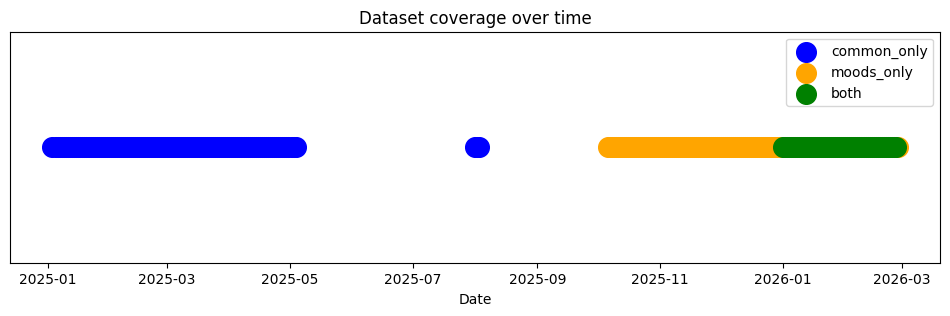

In [29]:
import matplotlib.pyplot as plt

from daily_flow.analytics.datasets.prepare import add_data_type, add_mood_flags

df = add_mood_flags(df)
df = add_data_type(df)

plt.figure(figsize=(12, 3))

mask_common = df["data_type"] == "common_only"
mask_moods = df["data_type"] == "moods_only"
mask_both = df["data_type"] == "both"

plt.scatter(
    df.index[mask_common], [1] * mask_common.sum(), color="blue", s=200, label="common_only"
)
plt.scatter(df.index[mask_moods], [1] * mask_moods.sum(), color="orange", s=200, label="moods_only")
plt.scatter(df.index[mask_both], [1] * mask_both.sum(), color="green", s=200, label="both")

plt.yticks([])
plt.xlabel("Date")
plt.title("Dataset coverage over time")
plt.legend()

plt.show()

The dataset is not continuously populated over time.
The coverage plot shows clear gaps and suggests three distinct logging regimes: days with only common_mood_log, days with only detailed mood features, and days where both are available.

## Dataset segmentation by logging regime
To formalize the visual pattern observed in the coverage timeline, I segment the dataset into contiguous periods with the same logging structure.

A new segment starts whenever the availability of:
- `common_mood_log`, or
- detailed mood features

changes relative to the previous day.

In [24]:
from daily_flow.analytics.datasets.segmentation import segment_df

df, segmented = segment_df(df)
segmented

,start,end,days,has_moods,has_common
segment_id,,,,,
1,2025-01-03,2025-08-03,123,False,True
2,2025-10-06,2025-12-31,87,True,False
3,2026-01-01,2026-02-26,57,True,True
4,2026-02-27,2026-02-27,1,True,False


The function assigns a new `segment_id` each time the data availability pattern changes.
As a result, each segment represents a contiguous period with a stable logging regime.

The initial segmentation reveals four periods with distinct logging patterns:

1. A period where only `common_mood_log` is available
2. A period where only detailed mood features are available
3. A period where both `common_mood_log` and detailed mood features are available
4. A short isolated one-day period that likely represents noise rather than a stable logging regime

At this stage, the segmentation provides an approximate structure of the dataset.  
However, it is still important to verify whether large gaps exist within these segments.

## Gap detection within segments
Although the initial segmentation identifies broad logging regimes, some segments may still contain large internal gaps.

To detect such cases, I split each segment into sub-segments whenever the gap between consecutive logged dates exceeds 5 days.

In [25]:
from daily_flow.analytics.datasets.segmentation import add_sub_segments, filter_short_sub_segments

df = add_sub_segments(df)
filtered_df, small_mask = filter_short_sub_segments(df, min_days=7, keep_first=True)
df[small_mask]

,common_mood_log,joy,interest,calm,energy,anxiety,sadness,irritation,fatigue,fear,confidence,sleep,has_common_mood_log,has_moods,data_type,state_change,segment_id,sub_segment,sub_days
day,,,,,,,,,,,,,,,,,,,
2025-08-01,4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True,False,common_only,False,1,1,3
2025-08-02,4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True,False,common_only,False,1,1,3
2025-08-03,4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,True,False,common_only,False,1,1,3


This check shows that the first segment contains a short isolated sub-period separated by a large time gap.

Since this sub-period is very short (`< 7` days), it is treated as noise rather than a meaningful continuation of the original regime.

## Filtering short isolated sub-periods
To obtain cleaner and more interpretable dataset regimes, I remove short sub-segments and run the segmentation procedure again.

In [26]:
filtered_df, resegmented = segment_df(filtered_df)

resegmented

,start,end,days,has_moods,has_common
segment_id,,,,,
1,2025-01-03,2025-05-04,120,False,True
2,2025-10-06,2025-12-31,87,True,False
3,2026-01-01,2026-02-26,57,True,True
4,2026-02-27,2026-02-27,1,True,False


After removing the short isolated sub-period, the dataset is reduced to three stable logging regimes:

1. `common_only` — only the general mood score is available
2. `moods_only` — only detailed mood features are available
3. `full` — both the general mood score and detailed mood features are available

These three regimes form the final structural decomposition of the dataset and will be used in the following EDA steps.

## Final period definitions
For convenience in the following analyses, I explicitly define the final time ranges corresponding to each logging regime.

In [27]:
from daily_flow.analytics.datasets.constants import FINAL_DATASET_PERIODS
from daily_flow.analytics.datasets.segmentation import slice_periods

dfs = slice_periods(filtered_df, FINAL_DATASET_PERIODS)

dfs["full"].tail()

,common_mood_log,joy,interest,calm,energy,anxiety,sadness,irritation,fatigue,fear,confidence,sleep,has_common_mood_log,has_moods,data_type,state_change,segment_id,sub_segment,sub_days
day,,,,,,,,,,,,,,,,,,,
2026-02-22,5,3,3,2,3,3,1,1,1,3,4,4,True,True,both,False,3,0,57
2026-02-23,6,4,4,3,4,2,1,1,1,1,3,4,True,True,both,False,3,0,57
2026-02-24,5,3,3,3,4,2,1,2,1,2,4,2,True,True,both,False,3,0,57
2026-02-25,3,2,3,2,2,2,2,2,3,1,4,3,True,True,both,False,3,0,57
2026-02-26,5,3,2,4,3,2,1,1,2,1,3,2,True,True,both,False,3,0,57


These slices will be used as period-specific datasets in subsequent notebooks.

This separation is important because not all features are available across the full timeline, and combining all periods into a single analysis would mix structurally different data-generating regimes.

## Summary

The exploratory analysis reveals that the dataset is not uniformly populated over time. 
Instead, it consists of three distinct logging regimes:

1. `common_only` — only the general mood score is available
2. `moods_only` — only detailed emotion features are available
3. `full` — both general mood and detailed emotion features are available

These regimes reflect changes in the logging process over time rather than random missing values.

To ensure clean analysis, short isolated periods were removed and the dataset was segmented into three stable regimes. 
These regimes will be analyzed separately in subsequent exploratory notebooks.

In [28]:
resegmented

,start,end,days,has_moods,has_common
segment_id,,,,,
1,2025-01-03,2025-05-04,120,False,True
2,2025-10-06,2025-12-31,87,True,False
3,2026-01-01,2026-02-26,57,True,True
4,2026-02-27,2026-02-27,1,True,False
